### "Шапка" с названием проекта

В этой ячейке вы найдете оглавление и ключевые этапы работы, которые помогут вам ориентироваться в процессе выполнения проекта. Проект разделен на пять основных этапов, четыре из которых (этапы 2, 3, 4 и 5) вам предлагается выполнить в этом Jupyter Notebook:

- Подготовка среды MLflow - Первый шаг, подготовка и запуск сервисов MLflow, был выполнен вне ноутбука и оформлен в виде shell скрипта. Это основа для работы с экспериментами и логирования результатов ваших моделей.

- Этап 2 - Исследовательский Анализ Данных (EDA): На этом этапе вы проведете тщательный анализ данных, чтобы лучше понять их структуру и особенности.

- Этап 3 - Генерация Признаков и Обучение Модели: После анализа данных вы сгенерируете новые признаки и обучите модель, используя эти признаки.

- Этап 4 - Отбор Признаков и Обучение Модели: На этом шаге вы отберете наиболее значимые признаки и снова обучите модель для улучшения ее качества.

- Этап 5 - Подбор Гиперпараметров и Обучение Финальной Версии Модели: Финальный этап проекта посвящен оптимизации гиперпараметров для достижения максимального качества модели.

Для удобства навигации и организации работы, пожалуйста, следуйте оглавлению и рекомендациям, описанным в каждом этапе.

> ### Важно: Переобучение моделей
> На каждом этапе проекта, где требуется переобучение модели, важно не просто выполнить эту процедуру, но и тщательно проверить качество модели на соответствующих выборках. Это включает в себя анализ метрик качества, визуализацию результатов, сравнение с предыдущими моделями и, при необходимости, корректировку.

> ### Важно: Разделение выборок
> Перед началом выполнения вашего проекта важно правильно подготовить данные, разделив их на подвыборки. Это позволит оценить производительность модели более объективно и управлять риском переобучения. В зависимости от ваших целей и доступных данных, вы можете использовать различные стратегии разделения:

1. Разделение на train/val/test: Это классический подход, где данные делятся на три части. Обучающая выборка (train) используется для первичного обучения моделей, валидационная (val) - для настройки гиперпараметров и выбора лучшей модели, а тестовая (test) - для финальной оценки производительности модели. Такой подход идеален, если у вас достаточно данных, чтобы разделить их и каждая из выборок была репрезентативна.

2. Разделение на train/test с кросс-валидацией на train: Если данных недостаточно для трех подвыборок, можно ограничиться разделением на обучающую и тестовую выборки. В этом случае кросс-валидация на обучающей выборке поможет оценить стабильность модели и подобрать гиперпараметры.

Определение способа разделения данных: Выбор метода разбиения данных на подвыборки — train, validation и test — должен быть обоснован особенностями вашего набора данных и задачами проекта. Возможные методы разделения, включая различные стратегии и правила, подробно описаны в [документации scikit-learn по разбиению данных](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html#sphx-glr-auto-examples-model-selection-plot-cv-indices-py). Вы можете следовать этим примерам или разработать собственный метод, исходя из специфики ваших данных.

Ваша задача - выбрать подходящий метод разделения данных исходя из объема и специфики ваших данных. Помните, что финальные метрики качества модели мы будем оценивать на тестовой выборке. Промежуточные результаты после каждого этапа проекта (например, после настройки гиперпараметров) следует оценивать на валидационной выборке, если таковая имеется. Это поможет вам корректно настроить модель перед финальной оценкой её производительности.

__Выбор: Разделение на train/val/test__

После загрузки из БД и подготовки доступно ~91 000 объектов — объёма достаточно для трёх репрезентативных подвыборок.

- данные загружаем из персональной БД (`flats_dataset_clean`), как в спринте 1;
- сначала выделяем **test** (20%), затем из оставшегося — **train/val** (val = 20% от train-части);
- **train** — обучение, **val** — сравнение моделей / отбор признаков / тюнинг, **test** — только финальная оценка и сравнение с baseline;
- вариант «train/test + CV» оставляем запасным: он полезен при малом объёме данных, здесь трёхстороннее разбиение проще и достаточно надёжно.


In [7]:
# Загрузка из персональной БД (как в спринте 1) и разбиение train/val/test.
# Без data_utils и без готовых CSV.

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import display
from sklearn.model_selection import train_test_split
from sqlalchemy import create_engine

# корень репозитория (для .env)
NB_DIR = Path.cwd().resolve()
if NB_DIR.name == "model_improvement":
    ROOT = NB_DIR.parent
else:
    ROOT = NB_DIR
    NB_DIR = ROOT / "model_improvement"
sys.path.insert(0, str(ROOT))
load_dotenv(ROOT / ".env")

SOURCE_TABLE = "flats_dataset_clean"
TARGET_COL = "price"
INDEX_COL = "flat_id"
TEST_SIZE = 0.2   # доля test от всего датасета
VAL_SIZE = 0.2    # доля val от оставшейся train-части
RANDOM_STATE = 42
ASSETS_DIR = NB_DIR / "artifacts"

sns.set_theme(style="whitegrid", context="notebook")


def ensure_assets_dir() -> Path:
    ASSETS_DIR.mkdir(parents=True, exist_ok=True)
    return ASSETS_DIR


def create_db_connection():
    """Подключение к персональной БД через DB_DESTINATION_*."""
    host = os.environ.get("DB_DESTINATION_HOST")
    port = os.environ.get("DB_DESTINATION_PORT")
    db = os.environ.get("DB_DESTINATION_NAME")
    user = os.environ.get("DB_DESTINATION_USER")
    password = os.environ.get("DB_DESTINATION_PASSWORD")

    missing = [
        k
        for k, v in [
            ("DB_DESTINATION_HOST", host),
            ("DB_DESTINATION_PORT", port),
            ("DB_DESTINATION_NAME", db),
            ("DB_DESTINATION_USER", user),
            ("DB_DESTINATION_PASSWORD", password),
        ]
        if not v
    ]
    if missing:
        raise RuntimeError(f"Не заданы переменные окружения: {', '.join(missing)}")

    return create_engine(
        f"postgresql://{user}:{password}@{host}:{port}/{db}",
        connect_args={"sslmode": "require"},
    )


def load_dataset_from_db(table: str = SOURCE_TABLE) -> pd.DataFrame:
    """Читает таблицу из PostgreSQL."""
    engine = create_db_connection()
    df = pd.read_sql(f"SELECT * FROM {table}", engine)
    engine.dispose()
    if INDEX_COL in df.columns:
        df = df.sort_values(INDEX_COL)
    return df.reset_index(drop=True)


def prepare_frame(df: pd.DataFrame) -> pd.DataFrame:
    """Базовая подготовка перед разбиением (как в спринте 1)."""
    out = df.dropna(subset=[TARGET_COL]).copy()
    out = out[out[TARGET_COL] > 0]
    if "total_area" in out.columns:
        out = out[out["total_area"] > 0]
    bool_cols = out.select_dtypes(include="bool").columns
    for col in bool_cols:
        out[col] = out[col].astype(int)
    return out.reset_index(drop=True)


def split_xy(df: pd.DataFrame):
    """Отделяет признаки и target."""
    y = df[TARGET_COL]
    drop_cols = [c for c in (TARGET_COL, INDEX_COL) if c in df.columns]
    return df.drop(columns=drop_cols), y


# загрузка из БД
df_raw = load_dataset_from_db()
df = prepare_frame(df_raw)

print(f"Таблица БД: {SOURCE_TABLE}")
print(f"Строк после подготовки: {len(df)}")

# разбиение на три группы: сначала test, затем val из оставшегося
train_val_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
)

# вывод статистики
n_train = len(train_df)
n_val = len(val_df)
n_test = len(test_df)
n_total = n_train + n_val + n_test

print(f"Train: {n_train} Val: {n_val} Test: {n_test}")
print(f"Всего: {n_total}")
print(f"Доля test: {n_test / n_total:.0%}")
print(f"Доля val (от train+val): {n_val / (n_train + n_val):.0%}")


Таблица БД: flats_dataset_clean
Строк после подготовки: 91000
Train: 58240 Val: 14560 Test: 18200
Всего: 91000
Доля test: 20%
Доля val (от train+val): 20%


In [8]:
# сохраняем оригинальные данные для контроьлных значений
train_raw, val_raw, test_raw = train_df.copy(), val_df.copy(), test_df.copy()

# разделяем признаки и метки
X_train, y_train = split_xy(train_df)
X_val, y_val = split_xy(val_df)
X_test, y_test = split_xy(test_df)


#### Этап 2: Исследовательский Анализ Данных (EDA)
На этом этапе ваша задача - провести тщательный исследовательский анализ данных (EDA), чтобы глубже понять особенности и связи в предоставленном наборе данных. В процессе EDA вы должны обратить внимание на три ключевых аспекта, о которых мы говорили в теме 3 курса. Очень важно, чтобы все результаты вашего исследования, включая визуализации, статистический анализ и предварительные выводы, были аккуратно залогированы в MLflow.

Для более организованного исследования предлагаем следующие рекомендуемые шаги:
- Понимание данных: Первоначально ознакомьтесь с данными, изучите типы данных, проверьте наличие пропущенных значений.
- Визуализация данных: Используйте графики и диаграммы для визуализации распределений признаков и возможных взаимосвязей между ними.
- Статистический анализ: Примените статистические методы для изучения центральных тенденций, разброса и корреляций между признаками.
- Предварительные выводы: На основе проведённого анализа сформулируйте предварительные выводы о данных, которые помогут в дальнейшем этапе моделирования.

Помните, что EDA - это итеративный процесс, в котором вы можете возвращаться к предыдущим шагам для дополнительного анализа, если это будет необходимо. Все находки и выводы должны быть чётко зафиксированы и легко доступны для команды проекта.


In [11]:
print(f"Типы данных в тренировочном наборе:")
print(train_df.dtypes)

# Пропуски
print(train_df.dtypes)
print(train_df.isna().sum().sort_values(ascending=False))
print("Всего пропусков:", int(train_df.isna().sum().sum()))

Типы данных в тренировочном наборе:
flat_id                int64
building_id            int64
floor                  int64
kitchen_area         float64
living_area          float64
rooms                  int64
is_apartment           int32
studio                 int32
total_area           float64
price                float64
build_year             int64
building_type_int      int64
latitude             float64
longitude            float64
ceiling_height       float64
flats_count            int64
floors_total           int64
has_elevator           int32
dtype: object
flat_id                int64
building_id            int64
floor                  int64
kitchen_area         float64
living_area          float64
rooms                  int64
is_apartment           int32
studio                 int32
total_area           float64
price                float64
build_year             int64
building_type_int      int64
latitude             float64
longitude            float64
ceiling_height       f

#### EDA Визуализация

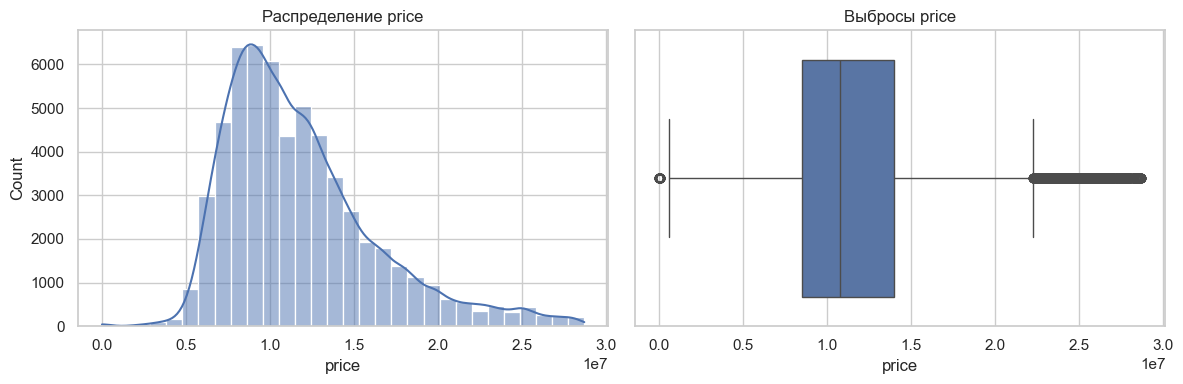

mean: 11800301.421377061
median: 10800000.0
skew: 1.129482285229084


In [12]:
# Распределение целевой переменной price
# для определения ассиметрии и выбросов target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_df[TARGET_COL], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Распределение price")
sns.boxplot(x=train_df[TARGET_COL], ax=axes[1])
axes[1].set_title("Выбросы price")
plt.tight_layout()
plt.show()
print("mean:", float(train_df[TARGET_COL].mean()))
print("median:", float(train_df[TARGET_COL].median()))
print("skew:", float(train_df[TARGET_COL].skew()))



__Вывод:__ целевая переменная ассиметрична, есть выбросы по ценам, нужно использовать модели устойчивые к выбросам, например log1p,  CatBoost / RMSE на log-scale

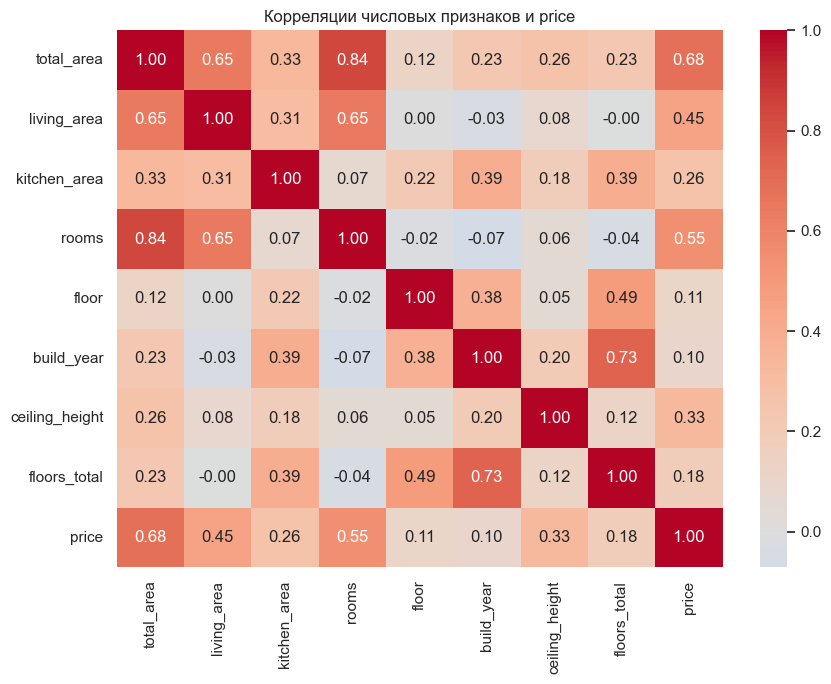

In [13]:
# Корреляции числовых признаков с price
# поиск числовых признаков, сильно связанных с price
num_cols = [
    c for c in [
        "total_area", "living_area", "kitchen_area", "rooms",
        "floor", "build_year", "ceiling_height", "floors_total",
    ]
    if c in train_df.columns
]
corr = train_df[num_cols + [TARGET_COL]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Корреляции числовых признаков и price")
plt.tight_layout()
plt.show()

__Вывод:__ 
- сильно связанные параметры с целевой переменной "total_area", "rooms".
- "total_area", "rooms" - также мультиколлинеарны. Главным признаком будем считать "total_area".

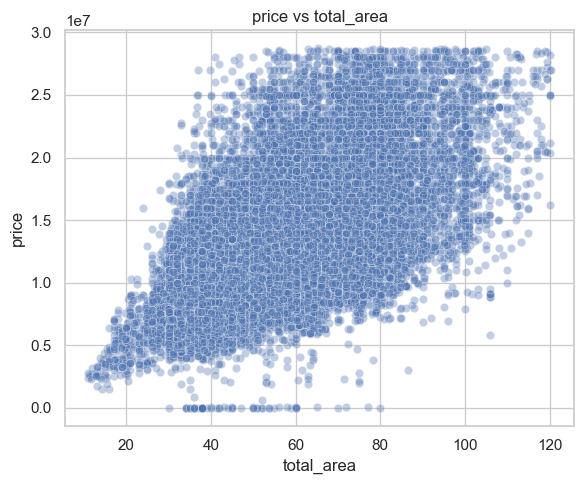

corr(total_area, price): 0.6790198670162318


In [14]:
# Связь площади и цены
# проверить главную гипотезу «больше площадь → выше цена»
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=train_df, x="total_area", y=TARGET_COL, alpha=0.35, ax=ax)
ax.set_title("price vs total_area")
plt.tight_layout()
plt.show()
print("corr(total_area, price):",
      float(train_df[["total_area", TARGET_COL]].corr().iloc[0, 1]))


__Выводы:__ 
- total_area — ключевой признак для модели; его нужно оставлять в любом пайплайне.
- Зависимость в среднем близка к линейной, но шум большой → полезны нелинейности (полиномы, биннинг, деревья/CatBoost) и дополнительные признаки.
- Рост медианы цены по квантилям площади подтверждает, что эффект стабильный по всему диапазону, а не только на хвостах.
= На этапе FE логично: total_area + полиномиальные/производные признаки площади, плюс признаки дома/категории, которые heatmap показал слабее линейно.

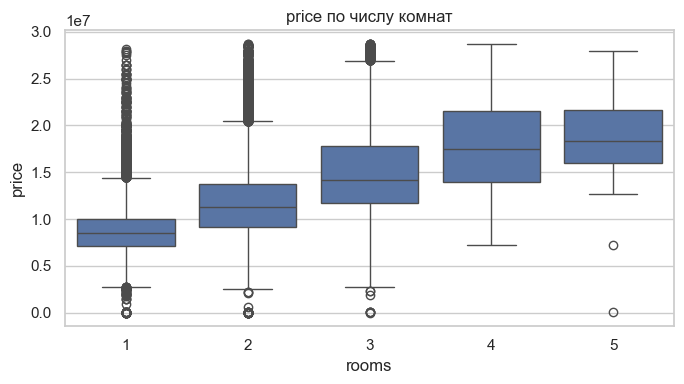

In [18]:
# Цена по числу комнат
# влияние дискретного фактора (число комнат) на цену — медианы и разброс по группам.
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=train_df, x="rooms", y=TARGET_COL, ax=ax)
ax.set_title("price по числу комнат")
plt.tight_layout()
plt.show()

__Выводы:__
- показывает устойчивый рост медианы с числом комнат: от ~8.5 млн (1 комн.) до ~17–19 млн (4–5 комн.), corr ≈ 0.56. 
- Основная масса объектов — 1–3 комнаты; 4–5 комнат редки. 
- Разброс цены внутри групп увеличивается с rooms. Часть влияния связана с площадью (больше комнат → больше м²), поэтому rooms важен как дискретный фактор, но его сигнал частично пересекается с total_area.
- Для моделирования признак оставляем и кодируем как категорию/порядковый, отдельно от полиномиальных преобразований площади.


### Статистические методы

In [19]:
# Центральные тенденции и разброс по всем числовым признакам
display(train_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
flat_id,58240.0,5.984825e+04,3.577563e+04,0.000000,2.844650e+04,5.900850e+04,9.045550e+04,1.240560e+05
building_id,58240.0,1.319540e+04,6.431236e+03,192.000000,8.178750e+03,1.287600e+04,1.854200e+04,2.462000e+04
floor,58240.0,6.719883e+00,4.503838e+00,1.000000,3.000000e+00,6.000000e+00,9.000000e+00,2.000000e+01
kitchen_area,58240.0,8.107058e+00,2.975992e+00,0.000000,6.000000e+00,8.400000e+00,1.000000e+01,1.630000e+01
living_area,58240.0,2.739144e+01,1.455989e+01,0.000000,1.900000e+01,2.830000e+01,3.600000e+01,7.400000e+01
rooms,58240.0,1.947356e+00,8.142496e-01,1.000000,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
is_apartment,58240.0,4.824863e-03,6.929405e-02,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
studio,58240.0,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
total_area,58240.0,5.163815e+01,1.618801e+01,11.000000,3.840000e+01,4.810000e+01,6.040000e+01,1.203000e+02
price,58240.0,1.180030e+07,4.503196e+06,19.000000,8.500000e+06,1.080000e+07,1.399900e+07,2.872000e+07


In [20]:
# Центральные тенденции и разброс по категориальным (уникальные, частоты)
display(train_df.describe(include="all").T.head(20))

,count,mean,std,min,25%,50%,75%,max
flat_id,58240.0,5.984825e+04,3.577563e+04,0.000000,2.844650e+04,5.900850e+04,9.045550e+04,1.240560e+05
building_id,58240.0,1.319540e+04,6.431236e+03,192.000000,8.178750e+03,1.287600e+04,1.854200e+04,2.462000e+04
floor,58240.0,6.719883e+00,4.503838e+00,1.000000,3.000000e+00,6.000000e+00,9.000000e+00,2.000000e+01
kitchen_area,58240.0,8.107058e+00,2.975992e+00,0.000000,6.000000e+00,8.400000e+00,1.000000e+01,1.630000e+01
living_area,58240.0,2.739144e+01,1.455989e+01,0.000000,1.900000e+01,2.830000e+01,3.600000e+01,7.400000e+01
rooms,58240.0,1.947356e+00,8.142496e-01,1.000000,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
is_apartment,58240.0,4.824863e-03,6.929405e-02,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
studio,58240.0,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
total_area,58240.0,5.163815e+01,1.618801e+01,11.000000,3.840000e+01,4.810000e+01,6.040000e+01,1.203000e+02
price,58240.0,1.180030e+07,4.503196e+06,19.000000,8.500000e+06,1.080000e+07,1.399900e+07,2.872000e+07


In [21]:
# Статистики целевой переменной price
print("mean:  ", float(train_df[TARGET_COL].mean()))
print("median:", float(train_df[TARGET_COL].median()))
print("std:   ", float(train_df[TARGET_COL].std()))
print("skew:  ", float(train_df[TARGET_COL].skew()))  # асимметрия

mean:   11800301.421377061
median: 10800000.0
std:    4503195.912991767
skew:   1.129482285229084


In [22]:
#Квантили price — где лежит основная масса цен
print(train_df[TARGET_COL].quantile([0.05, 0.25, 0.5, 0.75, 0.95]))

0.05     6400000.0
0.25     8500000.0
0.50    10800000.0
0.75    13999000.0
0.95    21000000.0
Name: price, dtype: float64


In [23]:
#Корреляции признаков с target (по модулю)
corr_target = (
    train_df.corr(numeric_only=True)[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=abs, ascending=False)
)
print("Топ корреляций с price:")
print(corr_target.head(10))


Топ корреляций с price:
total_area           0.679020
rooms                0.554552
living_area          0.450234
ceiling_height       0.326997
kitchen_area         0.264664
building_type_int   -0.210994
floors_total         0.177950
longitude           -0.136893
floor                0.111400
build_year           0.098196
Name: price, dtype: float64


In [24]:
# Парная корреляция ключевого признака
print(
    "corr(total_area, price):",
    float(train_df[["total_area", TARGET_COL]].corr().iloc[0, 1]),
)

corr(total_area, price): 0.6790198670162318


### Предварительные выводы
1. `price` имеет правый хвост (skew ≈ 1.1, mean > median). Для обучения целесообразны модели, устойчивые к выбросам. Нужна проверка аномально низких цен.
2. Сильнее всего с ценой связаны размерные признаки: `total_area` (corr ≈ 0.68), `rooms` (≈ 0.56), `living_area` (≈ 0.45). Площадь — ядро feature engineering (в т.ч. полиномы/биннинг); `rooms` кодировать как дискретный фактор отдельно.
3. Между `total_area`, `living_area` и `rooms` высокая взаимная корреляция — риск мультиколлинеарности для линейных моделей; понадобятся регуляризация и/или отбор признаков (forward/backward).
4. `build_year` и `floor` слабо коррелируют линейно с `price`, но могут быть полезны нелинейно; категориальные признаки (`building_type_int`, флаги, при необходимости `building_id`) кодировать отдельно от числовых преобразований.
5. Данных достаточно для схемы train/val/test: промежуточный выбор моделей и гиперпараметров — на val, финальное сравнение с baseline — только на test.



In [ ]:

# (резерв) — при необходимости перелогируйте notebook после полного заполнения шаблона


#### Этап 3: Генерация Признаков и Обучение Новой Версии Модели
После тщательного исследовательского анализа данных (EDA), вы, скорее всего, сформировали несколько гипотез относительно новых признаков, которые могут улучшить качество вашей модели. На этом этапе, мы предлагаем вам приступить к генерации новых признаков и последующему обучению модели, используя два подхода:

Ручная генерация признаков: Используйте ваше понимание данных и результаты EDA для создания новых признаков.
Автоматическая генерация признаков: Воспользуйтесь библиотеками для автоматической генерации признаков, чтобы облегчить и ускорить этот процесс.
Важно: Для признаков, созданных вручную, рекомендуется использовать объекты sklearn, такие как Pipeline и ColumnTransformer. Это позволит автоматизировать процесс преобразования данных и облегчить поддержку вашего проекта.

После генерации новых признаков, наступает время обучить новую версию вашей модели, используя эти признаки. Не забудьте залогировать все результаты, включая новые признаки, параметры модели и метрики качества, в MLflow для удобства отслеживания изменений и результатов.

Рекомендуемые шаги:

- Определение и генерация новых признаков на основе ваших гипотез.
- Использование библиотек для автоматической генерации признаков, если это применимо.
- Интеграция новых признаков в вашу модель с помощью Pipeline или ColumnTransformer для ручно созданных признаков.
- Обучение новой версии модели с использованием всех доступных признаков.
- Логирование результатов в MLflow для документирования и анализа эффективности новых признаков и модели.

Этот этап проекта критически важен для повышения точности и эффективности вашей модели. Тщательная работа на этом этапе может существенно повлиять на итоговое качество моделирования.


In [25]:
# ручная генерация признаков
# Инженерные признаки на основе EDA: 
# доли площадей, отношение этажа, возраст дома.

def add_engineered_columns(X: pd.DataFrame) -> pd.DataFrame:
    out = X.copy()
    if {"total_area", "living_area"}.issubset(out.columns):
        out["living_share"] = out["living_area"] / out["total_area"].clip(lower=1e-3)
    if {"total_area", "kitchen_area"}.issubset(out.columns):
        out["kitchen_share"] = out["kitchen_area"] / out["total_area"].clip(lower=1e-3)
    if {"floor", "floors_total"}.issubset(out.columns):
        out["floor_ratio"] = out["floor"] / out["floors_total"].clip(lower=1)
    if "build_year" in out.columns:
        out["house_age"] = 2024 - out["build_year"]
    return out

X_train_fe = add_engineered_columns(X_train)
X_val_fe = add_engineered_columns(X_val)
X_test_fe = add_engineered_columns(X_test)

print("новые колонки:", [c for c in X_train_fe.columns if c not in X_train.columns])
display(X_train_fe.head())


новые колонки: ['living_share', 'kitchen_share', 'floor_ratio', 'house_age']


,building_id,floor,kitchen_area,living_area,rooms,is_apartment,studio,total_area,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total,has_elevator,living_share,kitchen_share,floor_ratio,house_age
84005,17373,9,8.5,21.000000,1,0,0,38.500000,1999,4,55.537415,37.538879,2.64,210,12,1,0.545455,0.220779,0.750000,25
45854,10781,6,6.0,20.000000,1,0,0,32.000000,1974,4,55.614292,37.699318,2.64,287,9,1,0.625000,0.187500,0.666667,50
85674,13839,6,8.0,0.000000,3,0,0,79.000000,1983,4,55.627396,37.718472,2.64,580,14,1,0.000000,0.101266,0.428571,41
19365,2669,5,11.0,52.000000,3,0,0,81.699997,1959,1,55.723923,37.782017,3.00,56,5,0,0.636475,0.134639,1.000000,65
44112,9022,4,6.0,38.799999,3,0,0,58.400002,1970,4,55.831177,37.662857,2.64,355,9,1,0.664384,0.102740,0.444444,54


In [30]:
# Группы колонок для ColumnTransformer
poly_cols = [c for c in [
    "total_area", "living_area", "kitchen_area", "living_share", "kitchen_share",
    "ceiling_height", "floor_ratio", "house_age",
] if c in X_train_fe.columns]

bin_cols = [c for c in [
    "total_area", "house_age", "floors_total", "flats_count",
] if c in X_train_fe.columns]

cat_cols = [c for c in [
    "building_type_int", "rooms", "is_apartment", "studio", "has_elevator",
] if c in X_train_fe.columns]

print("poly_cols:", poly_cols)
print("bin_cols:", bin_cols)
print("cat_cols:", cat_cols)


poly_cols: ['total_area', 'living_area', 'kitchen_area', 'living_share', 'kitchen_share', 'ceiling_height', 'floor_ratio', 'house_age']
bin_cols: ['total_area', 'house_age', 'floors_total', 'flats_count']
cat_cols: ['building_type_int', 'rooms', 'is_apartment', 'studio', 'has_elevator']


In [ ]:
# Комментарий по предобработке 
# - StandardScaler: нормализация непрерывных признаков перед PolynomialFeatures
# - OneHotEncoder: rooms, building_type_int, bool-флаги
# - KBinsDiscretizer: дискретизация ключевых числовых признаков


In [31]:
# оборачивание всех преобразований в объекты sklearn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    KBinsDiscretizer,
    OneHotEncoder,
    PolynomialFeatures,
    StandardScaler,
)
from catboost import CatBoostRegressor

numeric_poly = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
])
numeric_bins = KBinsDiscretizer(n_bins=3, encode="onehot-dense", strategy="quantile")

transformers = [
    ("poly", numeric_poly, poly_cols),
    ("kbins", numeric_bins, bin_cols),
    ("cats", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
]
preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")

model_cb = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
)
pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model_cb)])
pipe


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('poly',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False))]),
                                                  ['total_area', 'living_area',
                                                   'kitchen_area',
                                                   'living_share',
                                                   'kitchen_share',
                                                   'ceiling_height',
                                                   'floor_ratio',
                                                   'house_age']),
                                                 ('kbins',
                                                  KBinsDiscretizer(encode='onehot-dense',
                                                                   n_bins=3),
                                                  ['total_area', 'house_age',
                                                   'floors_total',
                                                   'flats_count']),
                                                 ('cats',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['building_type_int', 'rooms',
                                                   'is_apartment', 'studio',
                                                   'has_elevator'])])),
                ('model',
                 <catboost.core.CatBoostRegressor object at 0x000001BD1B2E3250>)])

In [33]:
# Проверка размерности после preprocess
X_fit_fe = pd.concat([X_train_fe, X_val_fe], axis=0)
y_fit = pd.concat([y_train, y_val], axis=0)
Xt = pipe.named_steps["preprocess"].fit_transform(X_fit_fe)
print("Это размер матрицы после всех преобразований ColumnTransformer:", np.asarray(Xt).shape)


Это размер матрицы после всех преобразований ColumnTransformer: (72800, 72)


In [34]:
print("Pipeline шаги:", list(pipe.named_steps.keys()))


Pipeline шаги: ['preprocess', 'model']


In [36]:
# автоматическая генерация признаков (autofeat)
from autofeat import AutoFeatRegressor

af_cols = poly_cols[:6]
af = AutoFeatRegressor(feateng_steps=1, featsel_runs=1, n_jobs=1, verbose=0)

X_tr_af = af.fit_transform(X_train_fe[af_cols].astype(float), y_train)
X_va_af = af.transform(X_val_fe[af_cols].astype(float))
X_te_af = af.transform(X_test_fe[af_cols].astype(float))

print("автосгенерированные признаки:", list(X_tr_af.columns))
print("в:", X_tr_af.shape[1])


автосгенерированные признаки: ['total_area', 'living_area', 'kitchen_area', 'living_share', 'kitchen_share', 'ceiling_height', 'living_area**3', 'kitchen_area**3', 'living_share**3', 'kitchen_share**3']
всего: 10


In [37]:
display(X_tr_af.head())


,total_area,living_area,kitchen_area,living_share,kitchen_share,ceiling_height,living_area**3,kitchen_area**3,living_share**3,kitchen_share**3
0,38.500000,21.000000,8.5,0.545455,0.220779,2.64,9261.000000,614.125,0.162284,0.010762
1,32.000000,20.000000,6.0,0.625000,0.187500,2.64,8000.000000,216.000,0.244141,0.006592
2,79.000000,0.000000,8.0,0.000000,0.101266,2.64,0.000000,512.000,0.000000,0.001038
3,81.699997,52.000000,11.0,0.636475,0.134639,3.00,140608.000000,1331.000,0.257836,0.002441
4,58.400002,38.799999,6.0,0.664384,0.102740,2.64,58411.068554,216.000,0.293263,0.001084


In [38]:
# Сравнение числа признаков: исходные vs autofeat
print("исходные af_cols:", len(af_cols), "→ autofeat:", X_tr_af.shape[1])


исходные af_cols: 6 → autofeat: 10


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def compute_metrics(y_true, y_pred) -> dict:
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }

In [41]:
# обучение новой версии модели
import time

# делаем A|B тест

# Ветка A: sklearn Pipeline + log1p(target)
t0 = time.perf_counter()
pipe.fit(X_fit_fe, np.log1p(y_fit))
train_time = time.perf_counter() - t0

t1 = time.perf_counter()
pred_val_pipe = np.expm1(pipe.predict(X_val_fe))
pred_test_pipe = np.expm1(pipe.predict(X_test_fe))
predict_time = time.perf_counter() - t1

metrics_val_pipe = compute_metrics(y_val, pred_val_pipe)
metrics_test_pipe = compute_metrics(y_test, pred_test_pipe)
print("Pipeline val:", metrics_val_pipe)
print("Pipeline test:", metrics_test_pipe)
print(f"train_time={train_time:.3f}s, predict_time={predict_time:.3f}s")


Pipeline val: {'rmse': 2958861.3458481305, 'mae': 2190908.668867171, 'r2': 0.5642170521697174}
Pipeline test: {'rmse': 3025010.922244502, 'mae': 2251283.6064018263, 'r2': 0.5448342264331374}
train_time=4.263s, predict_time=0.357s


In [42]:
# Ветка B: autofeat + CatBoost + log1p(target)
X_af_fit = pd.concat([X_tr_af, X_va_af], axis=0)
cb_af = CatBoostRegressor(
    iterations=500, learning_rate=0.05, depth=6, loss_function="RMSE",
    random_seed=RANDOM_STATE, verbose=False, allow_writing_files=False,
)
cb_af.fit(X_af_fit, np.log1p(y_fit))
pred_val_af = np.expm1(cb_af.predict(X_va_af))
pred_test_af = np.expm1(cb_af.predict(X_te_af))
metrics_val_af = compute_metrics(y_val, pred_val_af)
metrics_test_af = compute_metrics(y_test, pred_test_af)
print("Autofeat val:", metrics_val_af)
print("Autofeat test:", metrics_test_af)


Autofeat val: {'rmse': 3131458.9659809214, 'mae': 2307009.648058691, 'r2': 0.5118936540659966}
Autofeat test: {'rmse': 3179084.675731629, 'mae': 2354559.2125330665, 'r2': 0.49728725628632897}


In [44]:
# Выбор лучшей ветки по test RMSE
use_autofeat = metrics_test_af["rmse"] < metrics_test_pipe["rmse"]
print("Лучшая ветка по test RMSE:", "autofeat" if use_autofeat else "pipeline")


Лучшая ветка по test RMSE: pipeline


In [45]:
# логирование артефактов в MLflow
# run = mle-project-sprint-2-run-003, model = mle-project-sprint-2-model-02
from mlflow.models import infer_signature
import json

STAGE03_DIR = ensure_assets_dir() / "stage03"
STAGE03_DIR.mkdir(parents=True, exist_ok=True)

metrics_payload = {
    "pipeline_val": metrics_val_pipe,
    "pipeline_test": metrics_test_pipe,
    "autofeat_val": metrics_val_af,
    "autofeat_test": metrics_test_af,
    "train_time_sec": train_time,
    "predict_time_sec": predict_time,
    "poly_cols": poly_cols,
    "bin_cols": bin_cols,
    "cat_cols": cat_cols,
    "target_transform": "log1p",
}
(STAGE03_DIR / "metrics.json").write_text(json.dumps(metrics_payload, ensure_ascii=False, indent=2), encoding="utf-8")

EXPERIMENT_NAME = STAGE_03["experiment"]
RUN_NAME = STAGE_03["run"]
REGISTRY_MODEL_NAME = STAGE_03["model"]
REQUIREMENTS = str(ROOT / "mlflow_server" / "requirements_baseline.txt")

setup_mlflow()
experiment_id = get_or_create_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    mlflow.set_tags({
        "stage": "03_feature_engineering",
        "selected_branch": "autofeat" if use_autofeat else "pipeline",
    })
    mlflow.log_params({
        "poly_degree": 2,
        "kbins": 5,
        "catboost_iterations": 500,
        "target_transform": "log1p",
        "n_poly_cols": len(poly_cols),
        "n_bin_cols": len(bin_cols),
        "n_cat_cols": len(cat_cols),
    })
    mlflow.log_metrics({f"val_{k}": v for k, v in metrics_val_pipe.items()})
    mlflow.log_metrics({f"test_{k}": v for k, v in metrics_test_pipe.items()})
    mlflow.log_metrics({f"autofeat_val_{k}": v for k, v in metrics_val_af.items()})
    mlflow.log_metrics({f"autofeat_test_{k}": v for k, v in metrics_test_af.items()})
    mlflow.log_metrics({
        "train_time_sec": train_time,
        "predict_time_sec": predict_time,
    })
    mlflow.log_artifact(str(STAGE03_DIR / "metrics.json"), artifact_path="metrics")

    if use_autofeat:
        signature = infer_signature(X_af_fit.head(20), np.expm1(cb_af.predict(X_af_fit.head(20))))
        mlflow.catboost.log_model(
            cb_model=cb_af,
            artifact_path="model",
            registered_model_name=REGISTRY_MODEL_NAME,
            signature=signature,
            input_example=X_te_af.head(5),
            pip_requirements=REQUIREMENTS,
            await_registration_for=60,
        )
        (STAGE03_DIR / "autofeat_features.json").write_text(
            json.dumps({"features": list(X_af_fit.columns)}, ensure_ascii=False, indent=2),
            encoding="utf-8",
        )
        mlflow.log_artifact(str(STAGE03_DIR / "autofeat_features.json"), artifact_path="autofeat")
    else:
        signature = infer_signature(X_fit_fe.head(20), np.expm1(pipe.predict(X_fit_fe.head(20))))
        mlflow.sklearn.log_model(
            sk_model=pipe,
            artifact_path="model",
            registered_model_name=REGISTRY_MODEL_NAME,
            signature=signature,
            input_example=X_test_fe.head(5),
            pip_requirements=REQUIREMENTS,
            await_registration_for=60,
        )
    print("Stage 3 logged:", RUN_NAME, run.info.run_id, "model=", REGISTRY_MODEL_NAME)


NameError: name 'STAGE_03' is not defined

In [ ]:
# baseline RMSE спринта 1 для сравнения
BASELINE_RMSE = 4847593.865795104
print("baseline RMSE:", BASELINE_RMSE)
print("pipeline test RMSE:", metrics_test_pipe["rmse"])
print("autofeat test RMSE:", metrics_test_af["rmse"])


#### Этап 4: Отбор Признаков и Обучение Новой Версии Модели
Создание новых признаков — это лишь часть работы. Следующий важный шаг — это убедиться в том, что каждый из этих признаков действительно вносит положительный вклад в качество модели. Некоторые признаки могут оказывать отрицательное влияние на модель, поэтому их следует исключить из анализа.

На этом этапе, мы рекомендуем вам применить различные методы отбора признаков для того, чтобы определить и удалить те признаки, которые не улучшают качество вашей модели. Цель этого этапа — максимизировать производительность модели, удалив избыточные или неинформативные признаки.

После тщательного отбора признаков, пора обучить новую версию вашей модели, уже без негативно влияющих на неё признаков. Важно залогировать результаты этого этапа, включая измененный набор признаков, параметры модели и полученные метрики качества, в MLflow для последующего анализа и сравнения.

Рекомендуемые шаги:

- Применение методов отбора признаков для идентификации и исключения признаков, ухудшающих качество модели.
- Анализ влияния каждого признака на модель, чтобы понять, какие из них наиболее ценные.
- Обучение новой версии модели без негативно влияющих признаков.
- Логирование всех изменений и результатов в MLflow, включая конечный набор признаков, параметры модели и метрики качества.

Этот этап не только поможет улучшить качество вашей модели, но и даст глубокое понимание о важности и влиянии отдельных признаков на результаты моделирования.


In [ ]:
# Отбор признаков — метод 1: Forward Sequential Feature Selection (mlxtend)
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import Ridge

def prepare_matrix(X: pd.DataFrame) -> pd.DataFrame:
    out = add_engineered_columns(X)
    for col in out.select_dtypes(include=["bool", "object"]).columns:
        out[col] = pd.Categorical(out[col]).codes
    return out.astype(float)

X_train_n = prepare_matrix(X_train)
X_val_n = prepare_matrix(X_val)
X_test_n = prepare_matrix(X_test)

k_features = (4, min(12, X_train_n.shape[1]))

sfs_fwd = SFS(
    Ridge(alpha=1.0, random_state=RANDOM_STATE),
    k_features=k_features,
    forward=True,
    floating=False,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1,
    verbose=0,
)
sfs_fwd.fit(X_train_n.values, np.log1p(y_train.values))
fwd_features = [X_train_n.columns[i] for i in sfs_fwd.k_feature_idx_]
print("forward features:", fwd_features)

STAGE04_DIR = ensure_assets_dir() / "stage04"
STAGE04_DIR.mkdir(parents=True, exist_ok=True)


In [ ]:
# История forward selection
metric_dict = sfs_fwd.get_metric_dict()
ks = sorted(metric_dict.keys())
scores = [-metric_dict[k]["avg_score"] for k in ks]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, scores, marker="o")
ax.set_xlabel("Число признаков")
ax.set_ylabel("CV RMSE (log-target)")
ax.set_title("Forward selection (SFS)")
plt.tight_layout()
fig.savefig(STAGE04_DIR / "sfs_forward.png", dpi=120)
plt.show()


In [ ]:
print("forward plot saved:", STAGE04_DIR / "sfs_forward.png")


In [ ]:
# 4.2 Отбор признаков — метод 2: Backward Sequential Feature Selection
sfs_bwd = SFS(
    Ridge(alpha=1.0, random_state=RANDOM_STATE),
    k_features=k_features,
    forward=False,
    floating=False,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1,
    verbose=0,
)
sfs_bwd.fit(X_train_n.values, np.log1p(y_train.values))
bwd_features = [X_train_n.columns[i] for i in sfs_bwd.k_feature_idx_]
print("backward features:", bwd_features)


In [ ]:
metric_dict = sfs_bwd.get_metric_dict()
ks = sorted(metric_dict.keys())
scores = [-metric_dict[k]["avg_score"] for k in ks]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, scores, marker="o")
ax.set_xlabel("Число признаков")
ax.set_ylabel("CV RMSE (log-target)")
ax.set_title("Backward selection (SBS)")
plt.tight_layout()
plt.show()
fig.savefig(STAGE04_DIR / "sfs_backward.png", dpi=120)


In [ ]:
print("n forward:", len(fwd_features), "n backward:", len(bwd_features))


In [ ]:
# 4.3 Сравнение наборов и финальный список признаков
def train_eval(cols):
    model = CatBoostRegressor(
        iterations=500, learning_rate=0.05, depth=6, loss_function="RMSE",
        random_seed=RANDOM_STATE, verbose=False, allow_writing_files=False,
    )
    X_fit = pd.concat([X_train_n[cols], X_val_n[cols]], axis=0)
    y_fit_local = pd.concat([y_train, y_val], axis=0)
    model.fit(X_fit, np.log1p(y_fit_local))
    val_m = compute_metrics(y_val, np.expm1(model.predict(X_val_n[cols])))
    test_m = compute_metrics(y_test, np.expm1(model.predict(X_test_n[cols])))
    return val_m, test_m, model, X_fit, y_fit_local

candidates = {
    "forward": fwd_features,
    "backward": bwd_features,
    "all": list(X_train_n.columns),
}
results = {}
best_name, best_pack = None, None
for name, cols in candidates.items():
    val_m, test_m, model, X_fit_sel, y_fit_sel = train_eval(cols)
    results[name] = {"features": cols, "val": val_m, "test": test_m}
    print(name, "val RMSE", val_m["rmse"], "test RMSE", test_m["rmse"])
    if best_pack is None or val_m["rmse"] < best_pack[0]["rmse"]:
        best_name = name
        best_pack = (val_m, test_m, model, cols, X_fit_sel, y_fit_sel)

val_metrics_sel, test_metrics_sel, model_sel, selected_features, X_fit_sel, y_fit_sel = best_pack
print("\nвыбран метод:", best_name)
print("признаки:", selected_features)


In [ ]:
# Важность признаков
imp_df = pd.DataFrame({
    "feature": selected_features,
    "importance": model_sel.get_feature_importance(),
}).sort_values("importance", ascending=False)
display(imp_df)

fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(selected_features))))
ax.barh(imp_df["feature"], imp_df["importance"])
ax.invert_yaxis()
ax.set_title("CatBoost feature importance")
plt.tight_layout()
plt.show()
fig.savefig(STAGE04_DIR / "feature_importance.png", dpi=120)
imp_df.to_csv(STAGE04_DIR / "feature_importance.csv", index=False)


In [ ]:
import json
(STAGE04_DIR / "selected_features.json").write_text(
    json.dumps({
        "method": best_name,
        "forward_features": fwd_features,
        "backward_features": bwd_features,
        "selected_features": selected_features,
        "test_metrics": test_metrics_sel,
    }, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print("saved", STAGE04_DIR / "selected_features.json")


In [ ]:
# 4.4 Обучение новой версии модели (уже обучена в 4.3 на train+val)
print("method:", best_name)
print("val:", val_metrics_sel)
print("test:", test_metrics_sel)


In [ ]:
# Сравнение с baseline
print("baseline RMSE:", BASELINE_RMSE)
print("selected test RMSE:", test_metrics_sel["rmse"])


In [ ]:
print("n_selected:", len(selected_features))


In [ ]:
# 4.5 Логирование всех артефактов в MLflow
# run = mle-project-sprint-2-run-004, model = mle-project-sprint-2-model-03
from mlflow.models import infer_signature

EXPERIMENT_NAME = STAGE_04["experiment"]
RUN_NAME = STAGE_04["run"]
REGISTRY_MODEL_NAME = STAGE_04["model"]
REQUIREMENTS = str(ROOT / "mlflow_server" / "requirements_baseline.txt")

setup_mlflow()
experiment_id = get_or_create_experiment(EXPERIMENT_NAME)
signature = infer_signature(X_fit_sel.head(20), np.expm1(model_sel.predict(X_fit_sel.head(20))))

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    mlflow.set_tags({"stage": "04_feature_selection", "selection_method": best_name})
    mlflow.log_params({
        "k_features_range": f"{k_features[0]}-{k_features[1]}",
        "n_selected": len(selected_features),
        "selected_features": ",".join(selected_features),
        "method": best_name,
        "target_transform": "log1p",
        "estimator_for_sfs": "Ridge",
    })
    mlflow.log_metrics({f"val_{k}": v for k, v in val_metrics_sel.items()})
    mlflow.log_metrics({f"test_{k}": v for k, v in test_metrics_sel.items()})
    for name in [
        "sfs_forward.png", "sfs_backward.png", "feature_importance.png",
        "feature_importance.csv", "selected_features.json",
    ]:
        p = STAGE04_DIR / name
        if p.exists():
            mlflow.log_artifact(str(p), artifact_path="selection")
    mlflow.catboost.log_model(
        cb_model=model_sel,
        artifact_path="model",
        registered_model_name=REGISTRY_MODEL_NAME,
        signature=signature,
        input_example=X_test_n[selected_features].head(5),
        pip_requirements=REQUIREMENTS,
        await_registration_for=60,
    )
    print("Stage 4 logged:", RUN_NAME, run.info.run_id)


In [ ]:
print("Этап 4 завершён")


In [ ]:
# отобранные признаки будут использованы на этапе 5
print(selected_features)


### Этап 5 - подбор гиперпараметров и обучение новой версии модели
После того как мы уделили значительное внимание качеству модели через создание и отбор признаков, пришло время для финального штриха — подбора гиперпараметров. Этот этап является ключевым в финальной части проекта второго спринта, где ваша задача — оптимизировать гиперпараметры модели для достижения наилучшего качества.

Рекомендуется подобрать гиперпараметры как минимум двумя различными методами (например, с использованием Grid Search и Random Search), чтобы вы могли сравнить результаты и выбрать наиболее эффективный набор гиперпараметров для вашей модели. После определения оптимальных гиперпараметров, наступает время обучить финальную версию модели, используя ваши новые признаки.

Рекомендуемые шаги:

- Выбор методов для подбора гиперпараметров: Определитесь с методами, которые вы будете использовать для подбора гиперпараметров (например, Grid Search, Random Search, Bayesian Optimization).
- Подбор гиперпараметров: Примените выбранные методы для нахождения оптимальных значений гиперпараметров вашей модели.
- Сравнение результатов: Анализируйте и сравнивайте результаты, полученные различными методами, для определения наилучшего набора гиперпараметров.
- Обучение финальной модели: Используя выбранные гиперпараметры, обучите финальную версию вашей модели на новых признаках.
- Документирование процесса и результатов: Залогируйте все шаги и результаты в MLflow, включая сравнение методов подбора гиперпараметров и характеристики финальной модели.

Этот этап позволит вам максимально улучшить качество вашей модели перед финальной оценкой, предоставив полное понимание важности и влияния гиперпараметров на производительность модели.

In [ ]:
# 5.1 Подбор гиперпараметров — метод 1: Optuna + MLflowCallback
import optuna
from optuna.integration.mlflow import MLflowCallback

N_OPTUNA_TRIALS = 25
N_RANDOM_ITER = 15

X_tr = X_train_n[selected_features]
X_va = X_val_n[selected_features]
X_te = X_test_n[selected_features]
X_cv = pd.concat([X_tr, X_va], axis=0)
y_cv = pd.concat([y_train, y_val], axis=0)
y_cv_log = np.log1p(y_cv)
y_tr_log = np.log1p(y_train)

setup_mlflow()
EXPERIMENT_NAME = STAGE_05["experiment"]
experiment_id = get_or_create_experiment(EXPERIMENT_NAME)

def objective(trial: optuna.Trial) -> float:
    params = {
        "iterations": trial.suggest_int("iterations", 300, 800),
        "depth": trial.suggest_int("depth", 4, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 12.0),
        "random_strength": trial.suggest_float("random_strength", 0.5, 2.0),
        "loss_function": "RMSE",
        "random_seed": RANDOM_STATE,
        "verbose": False,
        "allow_writing_files": False,
    }
    model = CatBoostRegressor(**params)
    model.fit(X_tr, y_tr_log)
    preds = np.expm1(model.predict(X_va))
    return float(np.sqrt(np.mean((y_val - preds) ** 2)))

mlflc = MLflowCallback(
    tracking_uri=mlflow.get_tracking_uri(),
    metric_name="val_rmse",
    create_experiment=False,
    mlflow_kwargs={"experiment_id": experiment_id},
)
study = optuna.create_study(direction="minimize", study_name="catboost_optuna_stage05")
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, callbacks=[mlflc])

optuna_best = study.best_params
optuna_best_rmse = float(study.best_value)
print("Optuna best RMSE:", optuna_best_rmse)
print("Optuna best params:", optuna_best)


In [ ]:
# История Optuna (best value по trials)
trials_df = study.trials_dataframe()
display(trials_df[["number", "value", "state"]].head(10))
print("best trial:", study.best_trial.number)


In [ ]:
print("n_trials:", len(study.trials))


In [ ]:
# 5.2 Подбор гиперпараметров — метод 2: RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

base = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
)
param_distributions = {
    "iterations": [300, 400, 500, 600, 800],
    "depth": [4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "l2_leaf_reg": [1.0, 3.0, 5.0, 8.0, 10.0],
}
search = RandomizedSearchCV(
    estimator=base,
    param_distributions=param_distributions,
    n_iter=N_RANDOM_ITER,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=0,
)
search.fit(X_cv, y_cv_log)
random_best = search.best_params_
print("RandomSearch best params:", random_best)


In [ ]:
# Оценка RandomSearch на val в исходной шкале price
tmp = CatBoostRegressor(
    **random_best, loss_function="RMSE", random_seed=RANDOM_STATE,
    verbose=False, allow_writing_files=False,
)
tmp.fit(X_tr, y_tr_log)
random_best_rmse = float(np.sqrt(np.mean((y_val - np.expm1(tmp.predict(X_va))) ** 2)))
print("RandomSearch val RMSE:", random_best_rmse)


In [ ]:
print("Optuna val RMSE:", optuna_best_rmse)
print("RandomSearch val RMSE:", random_best_rmse)


In [ ]:
# 5.3 Формирование списка гиперпараметров для новой модели
if optuna_best_rmse <= random_best_rmse:
    best_params = dict(optuna_best)
    winner = "optuna"
    winner_val_rmse = optuna_best_rmse
else:
    best_params = dict(random_best)
    winner = "randomized_search"
    winner_val_rmse = random_best_rmse

print("winner:", winner)
print("best_params:", best_params)


In [ ]:
# Сводка методов
pd.DataFrame([
    {"method": "optuna", "val_rmse": optuna_best_rmse},
    {"method": "randomized_search", "val_rmse": random_best_rmse},
    {"method": "winner", "val_rmse": winner_val_rmse},
])


In [ ]:
print("selected_features used:", selected_features)


In [ ]:
# 5.4 Обучение финальной версии модели
final_model = CatBoostRegressor(
    **best_params,
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
)
final_model.fit(X_cv, y_cv_log)

val_metrics_final = compute_metrics(y_val, np.expm1(final_model.predict(X_va)))
test_metrics_final = compute_metrics(y_test, np.expm1(final_model.predict(X_te)))
print("val:", val_metrics_final)
print("test:", test_metrics_final)


In [ ]:
# Сравнение с предыдущими версиями / baseline
comparison = pd.DataFrame([
    {"model": "baseline (sprint1)", "test_rmse": BASELINE_RMSE},
    {"model": "stage3 pipeline", "test_rmse": metrics_test_pipe["rmse"]},
    {"model": "stage3 autofeat", "test_rmse": metrics_test_af["rmse"]},
    {"model": "stage4 selection", "test_rmse": test_metrics_sel["rmse"]},
    {"model": "stage5 final", "test_rmse": test_metrics_final["rmse"]},
])
display(comparison)
print("улучшение RMSE vs baseline:", BASELINE_RMSE - test_metrics_final["rmse"])


In [ ]:
print("winner method:", winner)
print("best_params:", best_params)


In [ ]:
# 5.5 Логирование артефактов в MLflow
# run = mle-project-sprint-2-run-005, model = mle-project-sprint-2-model-04
from mlflow.models import infer_signature
import json

STAGE05_DIR = ensure_assets_dir() / "stage05"
STAGE05_DIR.mkdir(parents=True, exist_ok=True)

hparams = {
    "selected_features": selected_features,
    "optuna_best_params": optuna_best,
    "optuna_best_val_rmse": optuna_best_rmse,
    "random_search_best_params": random_best,
    "random_search_val_rmse": random_best_rmse,
    "winner": winner,
    "best_params": best_params,
    "val_metrics": val_metrics_final,
    "test_metrics": test_metrics_final,
    "target_transform": "log1p",
    "baseline_rmse_sprint1": BASELINE_RMSE,
}
(STAGE05_DIR / "hparams.json").write_text(json.dumps(hparams, ensure_ascii=False, indent=2), encoding="utf-8")

RUN_NAME = STAGE_05["run"]
REGISTRY_MODEL_NAME = STAGE_05["model"]
REQUIREMENTS = str(ROOT / "mlflow_server" / "requirements_baseline.txt")

signature = infer_signature(X_cv.head(20), np.expm1(final_model.predict(X_cv.head(20))))

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    mlflow.set_tags({
        "stage": "05_hyperparameter_tuning",
        "hp_winner": winner,
        "methods": "optuna,randomized_search",
    })
    mlflow.log_params({f"best_{k}": v for k, v in best_params.items()})
    mlflow.log_params({
        "n_optuna_trials": N_OPTUNA_TRIALS,
        "n_random_iter": N_RANDOM_ITER,
        "n_features": len(selected_features),
        "selected_features": ",".join(selected_features),
        "winner": winner,
        "target_transform": "log1p",
    })
    mlflow.log_metrics({
        "optuna_best_val_rmse": optuna_best_rmse,
        "random_search_val_rmse": random_best_rmse,
        "winner_val_rmse": winner_val_rmse,
        "baseline_rmse": BASELINE_RMSE,
        **{f"val_{k}": v for k, v in val_metrics_final.items()},
        **{f"test_{k}": v for k, v in test_metrics_final.items()},
    })
    mlflow.log_artifact(str(STAGE05_DIR / "hparams.json"), artifact_path="hparams")
    mlflow.catboost.log_model(
        cb_model=final_model,
        artifact_path="model",
        registered_model_name=REGISTRY_MODEL_NAME,
        signature=signature,
        input_example=X_te.head(5),
        pip_requirements=REQUIREMENTS,
        await_registration_for=60,
    )
    print("Stage 5 logged:", RUN_NAME, run.info.run_id, "model=", REGISTRY_MODEL_NAME)


In [ ]:
print("Проект (этапы 2–5) в notebook завершён.")
print("UI MLflow: http://127.0.0.1:5000")


In [ ]:
# Итоговые имена в MLflow
print("experiment = mle-project-sprint-2")
print("runs: run-002 (EDA), run-003 (FE), run-004 (FS), run-005 (HP)")
print("models: model-02, model-03, model-04")
